In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, MobileNet
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

2026-05-16 15:47:09.593975: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778946429.848288      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778946429.915537      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778946430.475153      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778946430.475209      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778946430.475214      57 computation_placer.cc:177] computation placer alr

In [ ]:
DATASET_PATH = "/kaggle/input/datasets/mdmahbubhassanaraf/breast-cancer-ultrasound-image/Dataset_BUSI_with_GT"

In [ ]:
import os

print(os.listdir(DATASET_PATH))

['benign', 'normal', 'malignant']


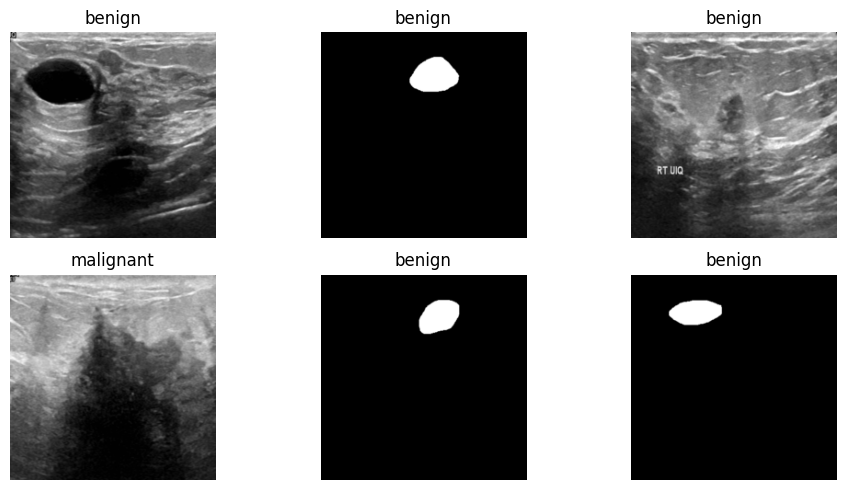

In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DATASET_PATH = "/kaggle/input/datasets/mdmahbubhassanaraf/breast-cancer-ultrasound-image/Dataset_BUSI_with_GT"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

loader = DataLoader(dataset, batch_size=6, shuffle=True)

images, labels = next(iter(loader))

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(dataset.classes[labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import random
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

IMG_SIZE = 224

temp_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

temp_dataset = datasets.ImageFolder(DATASET_PATH, transform=temp_transform)
temp_loader = DataLoader(temp_dataset, batch_size=32, shuffle=False)

mean = 0.
std = 0.
total_pixels = 0

for images, _ in temp_loader:
    batch_pixels = images.size(0) * images.size(2) * images.size(3)

    mean += images.sum(dim=[0, 2, 3])
    std += (images ** 2).sum(dim=[0, 2, 3])
    total_pixels += batch_pixels

mean = mean / total_pixels
std = torch.sqrt(std / total_pixels - mean ** 2)

print("Dataset Mean:", mean)
print("Dataset Std:", std)

normalize = transforms.Normalize(
    mean=mean.cpu().tolist(),
    std=std.cpu().tolist()
)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    normalize
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

base_dataset = datasets.ImageFolder(DATASET_PATH)

print("Classes:", base_dataset.classes)

targets = np.array(base_dataset.targets)

train_idx, val_idx, test_idx = [], [], []

for class_id in np.unique(targets):
    class_indices = np.where(targets == class_id)[0]
    np.random.shuffle(class_indices)

    n = len(class_indices)
    train_split = int(0.7 * n)
    val_split = int(0.85 * n)

    train_idx.extend(class_indices[:train_split])
    val_idx.extend(class_indices[train_split:val_split])
    test_idx.extend(class_indices[val_split:])

train_dataset = datasets.ImageFolder(DATASET_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(DATASET_PATH, transform=test_transform)
test_dataset  = datasets.ImageFolder(DATASET_PATH, transform=test_transform)

train_data = Subset(train_dataset, train_idx)
val_data   = Subset(val_dataset, val_idx)
test_data  = Subset(test_dataset, test_idx)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

labels = [base_dataset.targets[i] for i in train_idx]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Train size:", len(train_data))
print("Val size:", len(val_data))
print("Test size:", len(test_data))

Dataset Mean: tensor([0.2008, 0.2008, 0.2008])
Dataset Std: tensor([0.2735, 0.2735, 0.2735])
Classes: ['benign', 'malignant', 'normal']
Train size: 1103
Val size: 237
Test size: 238


**Normal CNN model**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_PATH = "/kaggle/working/best_cnn.pth"

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn_model = CNN(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, cnn_model.parameters()),
    lr=3e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.5
)

EPOCHS = 15
best_val_acc = 0.0

CNN_train_loss = []
CNN_val_loss = []
CNN_train_acc_list = []
CNN_val_acc_list = []
CNN_loss_list = []
for epoch in range(EPOCHS):

    cnn_model.train()

    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = cnn_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = train_loss / total
    CNN_train_loss.append(train_loss)
    train_acc = 100 * correct / total

    cnn_model.eval()

    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = cnn_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / val_total
    CNN_val_loss.append(val_loss)
    val_acc = 100 * val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(cnn_model.state_dict(), SAVE_PATH)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.2f}%")

    CNN_train_acc_list.append(train_acc)
    CNN_val_acc_list.append(val_acc)
    CNN_loss_list.append(train_loss)

    scheduler.step()

Epoch [1/15] Loss: 0.9503 Train Acc: 53.85% Val Loss: 1.0159 Val Acc: 40.08%
Epoch [2/15] Loss: 0.8444 Train Acc: 52.04% Val Loss: 0.9254 Val Acc: 44.30%
Epoch [3/15] Loss: 0.7773 Train Acc: 57.84% Val Loss: 0.8510 Val Acc: 51.90%
Epoch [4/15] Loss: 0.7494 Train Acc: 65.28% Val Loss: 0.8094 Val Acc: 57.81%
Epoch [5/15] Loss: 0.7261 Train Acc: 62.65% Val Loss: 0.8126 Val Acc: 56.96%
Epoch [6/15] Loss: 0.6999 Train Acc: 67.36% Val Loss: 0.7931 Val Acc: 61.18%
Epoch [7/15] Loss: 0.7089 Train Acc: 64.91% Val Loss: 0.7863 Val Acc: 60.76%
Epoch [8/15] Loss: 0.7010 Train Acc: 66.00% Val Loss: 0.7865 Val Acc: 59.49%
Epoch [9/15] Loss: 0.6735 Train Acc: 65.91% Val Loss: 0.7827 Val Acc: 61.18%
Epoch [10/15] Loss: 0.6731 Train Acc: 67.72% Val Loss: 0.7736 Val Acc: 62.87%
Epoch [11/15] Loss: 0.6699 Train Acc: 68.09% Val Loss: 0.7843 Val Acc: 59.49%
Epoch [12/15] Loss: 0.6607 Train Acc: 68.99% Val Loss: 0.7688 Val Acc: 62.87%
Epoch [13/15] Loss: 0.6726 Train Acc: 67.72% Val Loss: 0.7767 Val Acc: 61

In [ ]:
print("Best Validation Accuracy:", best_val_acc)

Best Validation Accuracy: 87.76371308016877


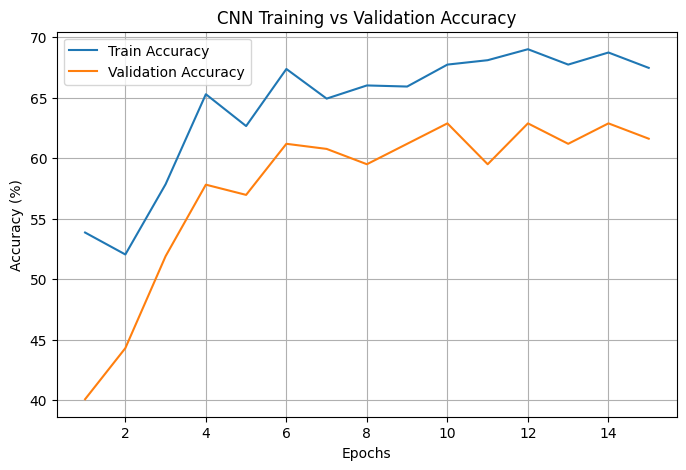

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(CNN_train_acc_list) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, CNN_train_acc_list, label='Train Accuracy')
plt.plot(epochs_range, CNN_val_acc_list, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('CNN Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

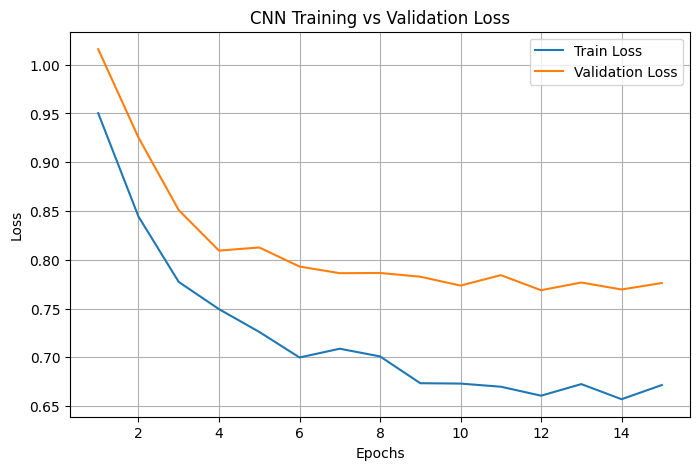

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(epochs_range, CNN_train_loss, label='Train Loss')
plt.plot(epochs_range, CNN_val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

**ResNet50 Model**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_PATH = "/kaggle/working/best_resnet.pth"

resnet_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

for param in resnet_model.layer4.parameters():
    param.requires_grad = True

resnet_model.fc = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 3)
)

resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-5
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.5
)

EPOCHS = 15
best_val_acc = 0.0

ResNet_train_loss = []
ResNet_val_loss = []
ResNet_train_acc_list = []
ResNet_val_acc_list = []
ResNet_loss_list = []

for epoch in range(EPOCHS):

    resnet_model.train()

    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = train_loss / total
    ResNet_train_loss.append(train_loss)
    train_acc = 100 * correct / total

    resnet_model.eval()

    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = resnet_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / val_total
    ResNet_val_loss.append(val_loss)
    val_acc = 100 * val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(resnet_model.state_dict(), SAVE_PATH)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.2f}%")

    ResNet_train_acc_list.append(train_acc)
    ResNet_val_acc_list.append(val_acc)
    ResNet_loss_list.append(train_loss)

    scheduler.step()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Epoch [1/15] Loss: 1.0192 Train Acc: 49.05% Val Loss: 0.9590 Val Acc: 57.81%
Epoch [2/15] Loss: 0.8344 Train Acc: 69.27% Val Loss: 0.7828 Val Acc: 67.93%
Epoch [3/15] Loss: 0.7316 Train Acc: 73.98% Val Loss: 0.7001 Val Acc: 78.48%
Epoch [4/15] Loss: 0.6723 Train Acc: 77.97% Val Loss: 0.6461 Val Acc: 82.70%
Epoch [5/15] Loss: 0.6403 Train Acc: 77.33% Val Loss: 0.6356 Val Acc: 82.28%
Epoch [6/15] Loss: 0.5959 Train Acc: 79.42% Val Loss: 0.6129 Val Acc: 83.54%
Epoch [7/15] Loss: 0.5836 Train Acc: 79.42% Val Loss: 0.5978 Val Acc: 83.12%
Epoch [8/15] Loss: 0.5689 Train Acc: 80.60% Val Loss: 0.5845 Val Acc: 84.39%
Epoch [9/15] Loss: 0.5462 Train Acc: 82.23% Val Loss: 0.5815 Val Acc: 83.54%
Epoch [10/15] Loss: 0.5584 Train Acc: 81.78% Val Loss: 0.5683 Val Acc: 83.12%
Epoch [11/15] Loss: 0.5568 Train Acc: 82.41% Val Loss: 0.5546 Val Acc: 84.81%
Epoch [12/15] Loss: 0.5389 Train Acc: 83.23% Val Loss: 0.5590 Val Acc: 84.81%
Epoch [13/15] Loss: 0.5355 Train Acc: 83.50% Val Loss: 0.5670 Val Acc: 84

In [ ]:
print("Best Validation accuracy :", best_val_acc)


Best Validation accuracy : 87.76371308016877


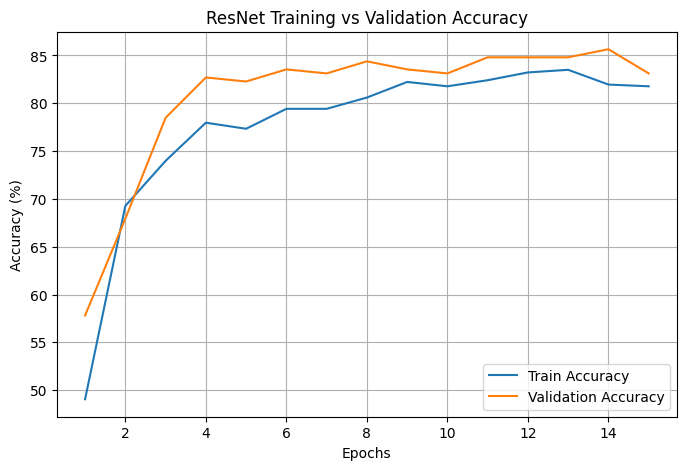

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(ResNet_train_acc_list) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, ResNet_train_acc_list, label="Train Accuracy")
plt.plot(epochs_range, ResNet_val_acc_list, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("ResNet Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

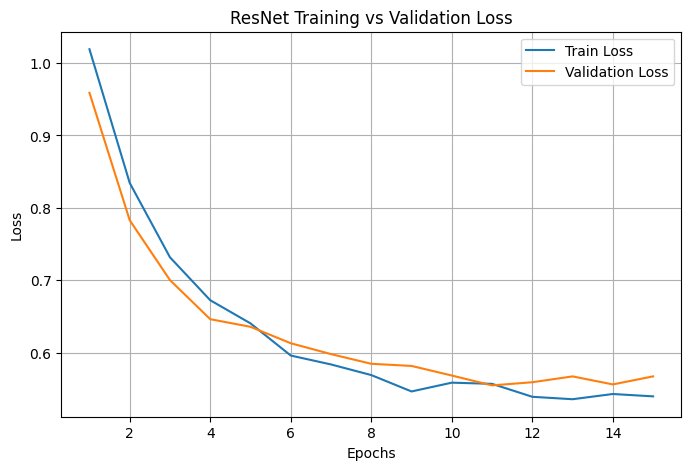

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(epochs_range, ResNet_train_loss, label="Train Loss")
plt.plot(epochs_range, ResNet_val_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ResNet Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

**Mobilenet Model**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_PATH = "/kaggle/working/best_mobilenet.pth"

mobilenet_model = models.mobilenet_v2(weights="IMAGENET1K_V1")

for param in mobilenet_model.features.parameters():
    param.requires_grad = True

mobilenet_model.classifier = nn.Sequential(
    nn.Linear(mobilenet_model.classifier[1].in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 3)
)

mobilenet_model = mobilenet_model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet_model.parameters()),
    lr=5e-5
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.5
)

EPOCHS = 15
best_val_acc = 0.0

Mobile_train_loss = []
Mobile_val_loss = []
Mobile_train_acc_list = []
Mobile_val_acc_list = []
Mobile_loss_list = []

for epoch in range(EPOCHS):

    mobilenet_model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = mobilenet_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = train_loss / total
    Mobile_train_loss.append(train_loss)
    train_acc = 100 * correct / total

    mobilenet_model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = mobilenet_model(images)

            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / val_total
    Mobile_val_loss.append(val_loss)
    val_acc = 100 * val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(mobilenet_model.state_dict(), SAVE_PATH)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.2f}%")

    Mobile_train_acc_list.append(train_acc)
    Mobile_val_acc_list.append(val_acc)
    Mobile_loss_list.append(train_loss)

    scheduler.step()

print("Best Validation accuracy :", best_val_acc)

mobilenet_model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
mobilenet_model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = mobilenet_model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total

print("Final Test Accuracy :", test_acc)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 147MB/s]


Epoch [1/15] Loss: 0.8402 Train Acc: 66.27% Val Loss: 0.6703 Val Acc: 71.73%
Epoch [2/15] Loss: 0.5407 Train Acc: 76.25% Val Loss: 0.4771 Val Acc: 80.59%
Epoch [3/15] Loss: 0.4113 Train Acc: 83.41% Val Loss: 0.4060 Val Acc: 81.86%
Epoch [4/15] Loss: 0.3510 Train Acc: 85.31% Val Loss: 0.3623 Val Acc: 83.12%
Epoch [5/15] Loss: 0.3026 Train Acc: 87.04% Val Loss: 0.3461 Val Acc: 84.81%
Epoch [6/15] Loss: 0.2850 Train Acc: 88.12% Val Loss: 0.3277 Val Acc: 85.65%
Epoch [7/15] Loss: 0.2687 Train Acc: 87.94% Val Loss: 0.3276 Val Acc: 86.92%
Epoch [8/15] Loss: 0.2688 Train Acc: 88.49% Val Loss: 0.3067 Val Acc: 86.50%
Epoch [9/15] Loss: 0.2687 Train Acc: 89.12% Val Loss: 0.2971 Val Acc: 87.34%
Epoch [10/15] Loss: 0.2531 Train Acc: 90.12% Val Loss: 0.3007 Val Acc: 86.50%
Epoch [11/15] Loss: 0.2378 Train Acc: 90.39% Val Loss: 0.3059 Val Acc: 87.76%
Epoch [12/15] Loss: 0.2597 Train Acc: 88.40% Val Loss: 0.2993 Val Acc: 87.76%
Epoch [13/15] Loss: 0.2415 Train Acc: 90.39% Val Loss: 0.3066 Val Acc: 86

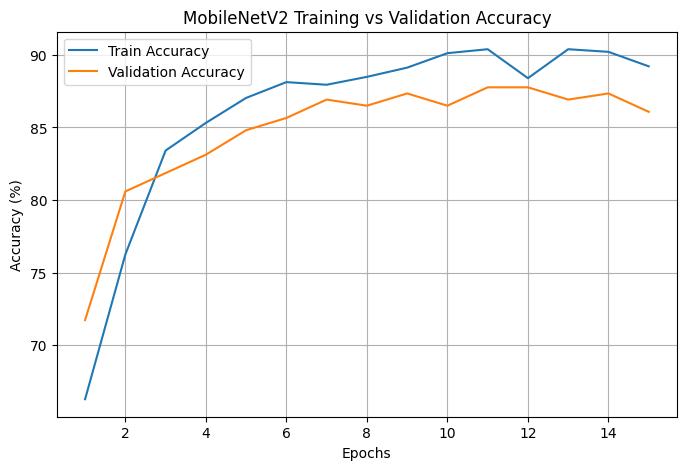

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(Mobile_train_acc_list) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, Mobile_train_acc_list, label="Train Accuracy")
plt.plot(epochs_range, Mobile_val_acc_list, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("MobileNetV2 Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

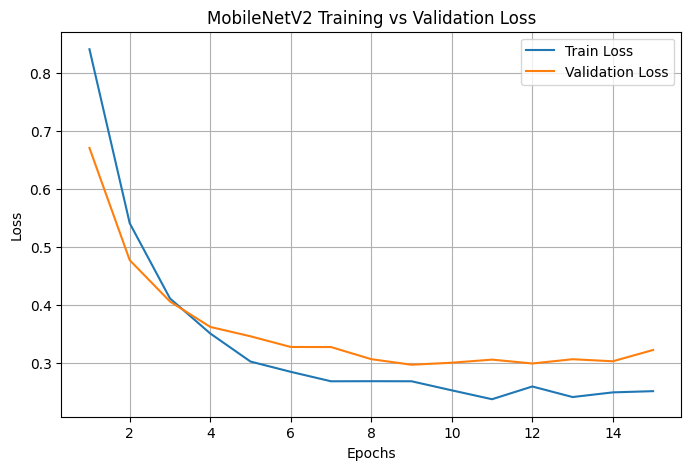

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(epochs_range, Mobile_train_loss, label="Train Loss")
plt.plot(epochs_range, Mobile_val_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

**Evaluation Report Normal CNN**

FINAL TEST MODEL REPORT
Accuracy  : 60.50%
Precision : 70.92%
Recall    : 60.50%
F1 Score  : 61.17%
RMSE      : 0.9937

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.49      0.62       134
           1       0.64      0.61      0.62        64
           2       0.40      0.97      0.57        40

    accuracy                           0.61       238
   macro avg       0.62      0.69      0.60       238
weighted avg       0.71      0.61      0.61       238



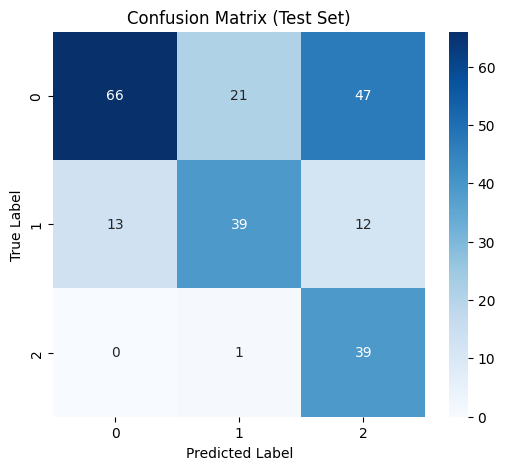

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_squared_error
)

cnn_model.load_state_dict(torch.load("best_cnn.pth", map_location=device))
cnn_model.to(device)
cnn_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = cnn_model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred, average='weighted') * 100
recall = recall_score(y_true, y_pred, average='weighted') * 100
f1 = f1_score(y_true, y_pred, average='weighted') * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("FINAL TEST MODEL REPORT")
print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")
print(f"RMSE      : {rmse:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Evaluation Report Resnet50**

FINAL TEST REPORT
Accuracy  : 83.61%
Precision : 84.17%
Recall    : 83.61%
F1 Score  : 83.77%
RMSE      : 0.5834

 Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       134
           1       0.78      0.84      0.81        64
           2       0.73      0.80      0.76        40

    accuracy                           0.84       238
   macro avg       0.80      0.83      0.82       238
weighted avg       0.84      0.84      0.84       238



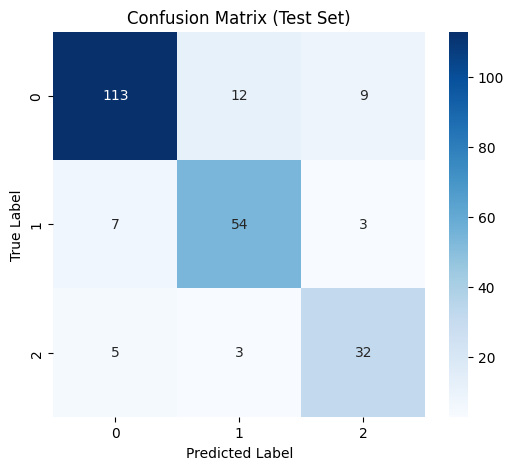

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_squared_error
)
resnet_model.load_state_dict(torch.load("best_resnet.pth", map_location=device))
resnet_model.to(device)
resnet_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred, average='weighted') * 100
recall = recall_score(y_true, y_pred, average='weighted') * 100
f1 = f1_score(y_true, y_pred, average='weighted') * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("FINAL TEST REPORT")
print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")
print(f"RMSE      : {rmse:.4f}")

print("\n Classification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Evaluation Report Mobilenet**

FINAL TEST MODEL REPORT
Accuracy  : 91.18%
Precision : 92.48%
Recall    : 91.18%
F1 Score  : 91.37%
RMSE      : 0.4491

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       134
           1       0.96      0.84      0.90        64
           2       0.74      1.00      0.85        40

    accuracy                           0.91       238
   macro avg       0.89      0.92      0.90       238
weighted avg       0.92      0.91      0.91       238



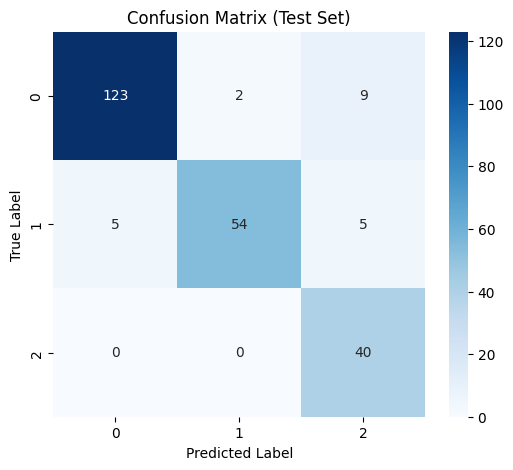

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_squared_error
)

mobilenet_model.load_state_dict(torch.load("best_mobilenet.pth", map_location=device))
mobilenet_model.to(device)
mobilenet_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = mobilenet_model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred, average='weighted') * 100
recall = recall_score(y_true, y_pred, average='weighted') * 100
f1 = f1_score(y_true, y_pred, average='weighted') * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("FINAL TEST MODEL REPORT")
print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")
print(f"RMSE      : {rmse:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Comparison**

In [ ]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error

def evaluate_model(model, dataloader, device):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average='weighted') * 100
    rec = recall_score(y_true, y_pred, average='weighted') * 100
    f1 = f1_score(y_true, y_pred, average='weighted') * 100

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return acc, prec, rec, f1, rmse

In [ ]:
import pandas as pd

cnn_metrics = evaluate_model(cnn_model, test_loader, device)
resnet_metrics = evaluate_model(resnet_model, test_loader, device)
mobilenet_metrics = evaluate_model(mobilenet_model, test_loader, device)

results = pd.DataFrame({
    "Model": ["CNN", "ResNet50", "MobileNetV2"],
    "Accuracy": [cnn_metrics[0], resnet_metrics[0], mobilenet_metrics[0]],
    "Precision": [cnn_metrics[1], resnet_metrics[1], mobilenet_metrics[1]],
    "Recall": [cnn_metrics[2], resnet_metrics[2], mobilenet_metrics[2]],
    "F1 Score": [cnn_metrics[3], resnet_metrics[3], mobilenet_metrics[3]],
    "RMSE": [cnn_metrics[4], resnet_metrics[4], mobilenet_metrics[4]],
})

print(results)

         Model   Accuracy  Precision     Recall   F1 Score      RMSE
0          CNN  60.504202   70.91839  60.504202  61.170987  0.993677
1     ResNet50  83.613445   84.16549  83.613445  83.770066  0.583383
2  MobileNetV2  91.176471   92.48300  91.176471  91.369474  0.449089


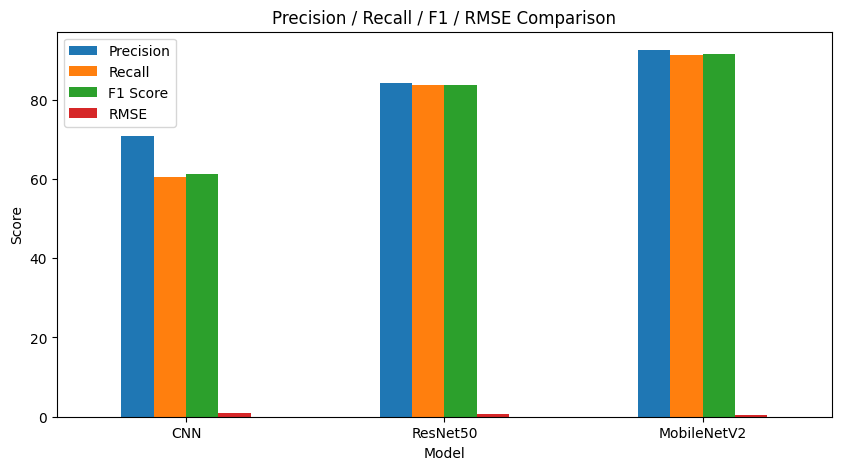

In [ ]:
results_plot = results.set_index("Model")[["Precision", "Recall", "F1 Score", "RMSE"]]

results_plot.plot(kind="bar", figsize=(10,5))
plt.title("Precision / Recall / F1 / RMSE Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [ ]:
import pandas as pd
import torch

def evaluate(model, dataloader, criterion, device):
    model.eval()

    correct = 0
    total = 0
    loss_total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    avg_loss = loss_total / total

    return acc, avg_loss

results = []

cnn_train_acc, _ = evaluate(cnn_model, train_loader, criterion, device)
cnn_val_acc, _   = evaluate(cnn_model, val_loader, criterion, device)
cnn_test_acc, _  = evaluate(cnn_model, test_loader, criterion, device)

results.append(["CNN", cnn_train_acc, cnn_val_acc, cnn_test_acc])



resnet_train_acc, _ = evaluate(resnet_model, train_loader, criterion, device)
resnet_val_acc, _   = evaluate(resnet_model, val_loader, criterion, device)
resnet_test_acc, _  = evaluate(resnet_model, test_loader, criterion, device)

results.append(["ResNet", resnet_train_acc, resnet_val_acc, resnet_test_acc])

mobilenet_train_acc, _ = evaluate(mobilenet_model, train_loader, criterion, device)
mobilenet_val_acc, _   = evaluate(mobilenet_model, val_loader, criterion, device)
mobilenet_test_acc, _  = evaluate(mobilenet_model, test_loader, criterion, device)

results.append(["MobileNet", mobilenet_train_acc, mobilenet_val_acc, mobilenet_test_acc])

df = pd.DataFrame(results, columns=[
    "Model",
    "Train Accuracy (%)",
    "Validation Accuracy (%)",
    "Test Accuracy (%)"
])

print(df)

       Model  Train Accuracy (%)  Validation Accuracy (%)  Test Accuracy (%)
0        CNN           69.356301                62.869198          60.504202
1     ResNet           87.398005                85.654008          83.613445
2  MobileNet           90.480508                87.763713          91.176471


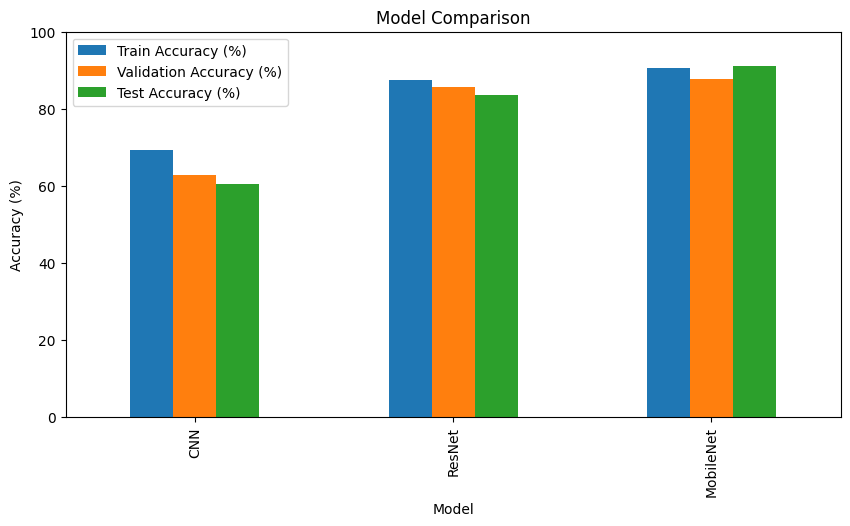

In [ ]:
import matplotlib.pyplot as plt

df.plot(x="Model", kind="bar", figsize=(10,5))
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.ylim(0, 100)
plt.show()

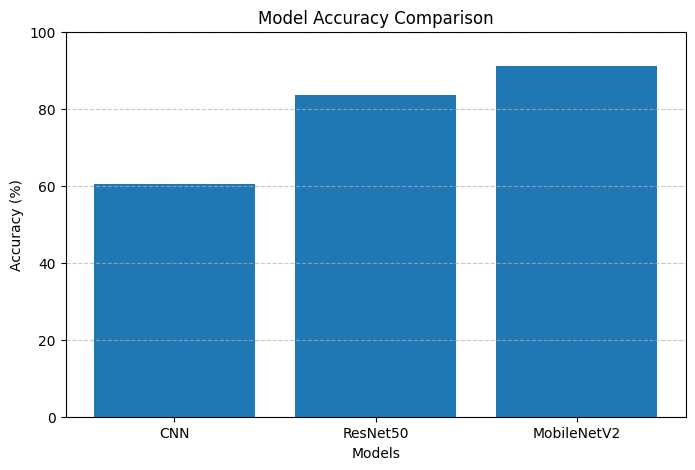

In [ ]:
import matplotlib.pyplot as plt

models = ["CNN", "ResNet50", "MobileNetV2"]

accuracy = [
    cnn_test_acc,
    resnet_test_acc,
    mobilenet_test_acc
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

**GradCAM**

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F
from PIL import Image
import matplotlib.cm as cm
mean = mean.cpu().tolist() if torch.is_tensor(mean) else mean
std  = std.cpu().tolist() if torch.is_tensor(std) else std

def denorm(img_tensor):
    img = img_tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = np.array(img)

    img = img * std + mean
    img = np.clip(img, 0, 1)

    return img
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_hook = target_layer.register_forward_hook(self.save_activation)
        self.bwd_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out.detach()

    def save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, x):
        self.model.eval()

        x = x.unsqueeze(0).to(device).requires_grad_(True)

        output = self.model(x)
        class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()

        cam = F.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy()

    def remove_hooks(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()
def overlay(image_tensor, heatmap):
    img = denorm(image_tensor)

    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((img.shape[1], img.shape[0]))
    heatmap = np.array(heatmap)

    heatmap = cm.jet(heatmap / 255.0)[..., :3]

    overlay_img = 0.55 * img + 0.45 * heatmap
    overlay_img = np.clip(overlay_img, 0, 1)

    return img, heatmap, overlay_img

def get_random_indices(dataset, n=8):
    return random.sample(range(len(dataset)), n)

def show_gradcam(gradcam, model_name, indices, dataset, class_names):

    fig, axes = plt.subplots(len(indices), 3, figsize=(12, len(indices)*3))
    fig.suptitle(f"{model_name} Grad-CAM Results", fontsize=14, fontweight="bold")

    for i, idx in enumerate(indices):

        img, label = dataset[idx]

        heatmap = gradcam.generate(img)
        orig, hm, overlay_img = overlay(img, heatmap)

        with torch.no_grad():
            pred = gradcam.model(img.unsqueeze(0).to(device)).argmax(1).item()

        color = "green" if pred == label else "red"

        axes[i, 0].imshow(orig)
        axes[i, 0].set_title(f"True: {class_names[label]}\nPred: {class_names[pred]}", color=color)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(hm)
        axes[i, 1].set_title("Grad-Cam Heatmap")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay_img)
        axes[i, 2].set_title("Overlay")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

cnn_layer = cnn_model.features[-2]
resnet_layer = resnet_model.layer4[-1]
mobilenet_layer = mobilenet_model.features[-1]
gradcam_cnn = GradCAM(cnn_model, cnn_layer)
gradcam_resnet = GradCAM(resnet_model, resnet_layer)
gradcam_mobilenet = GradCAM(mobilenet_model, mobilenet_layer)

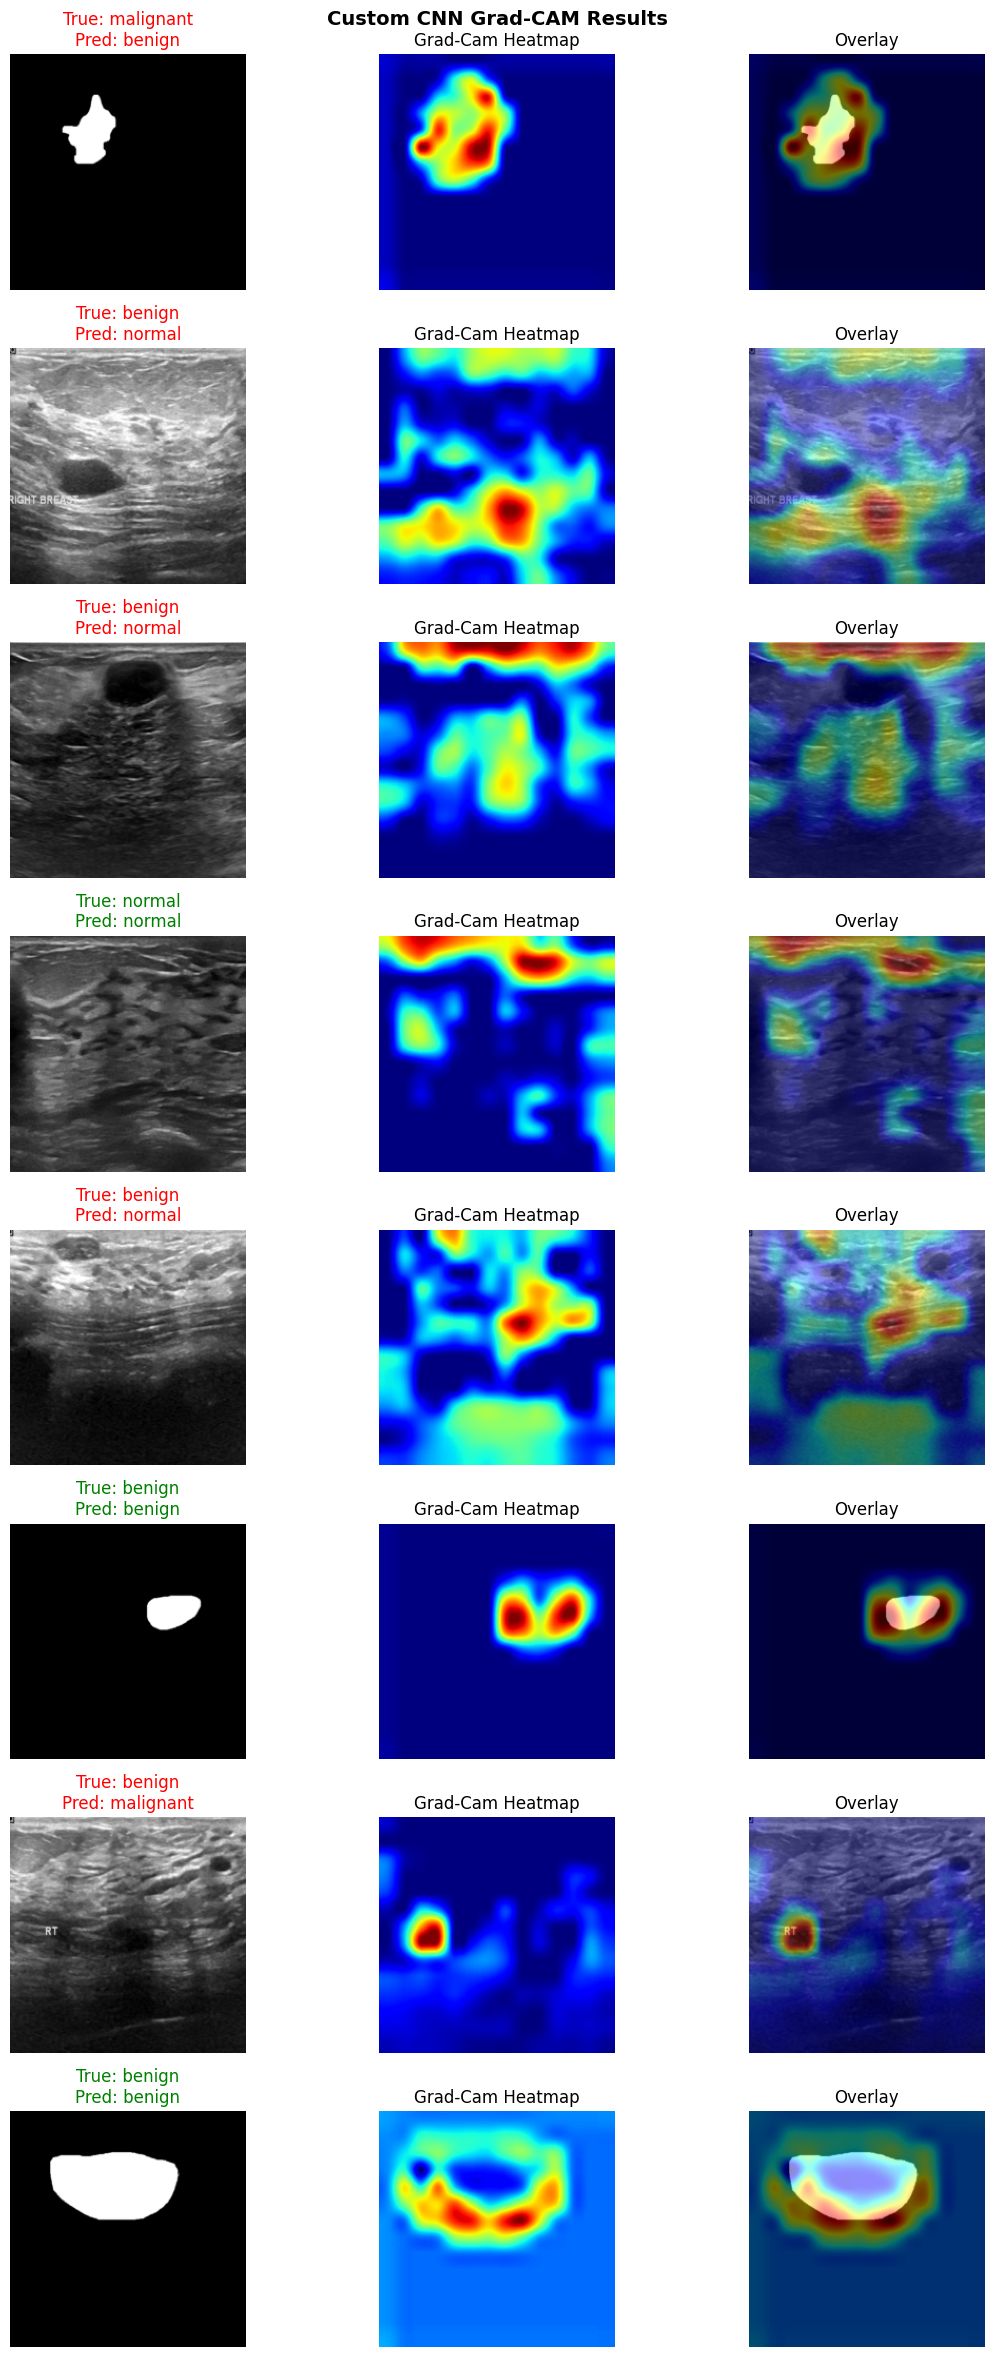

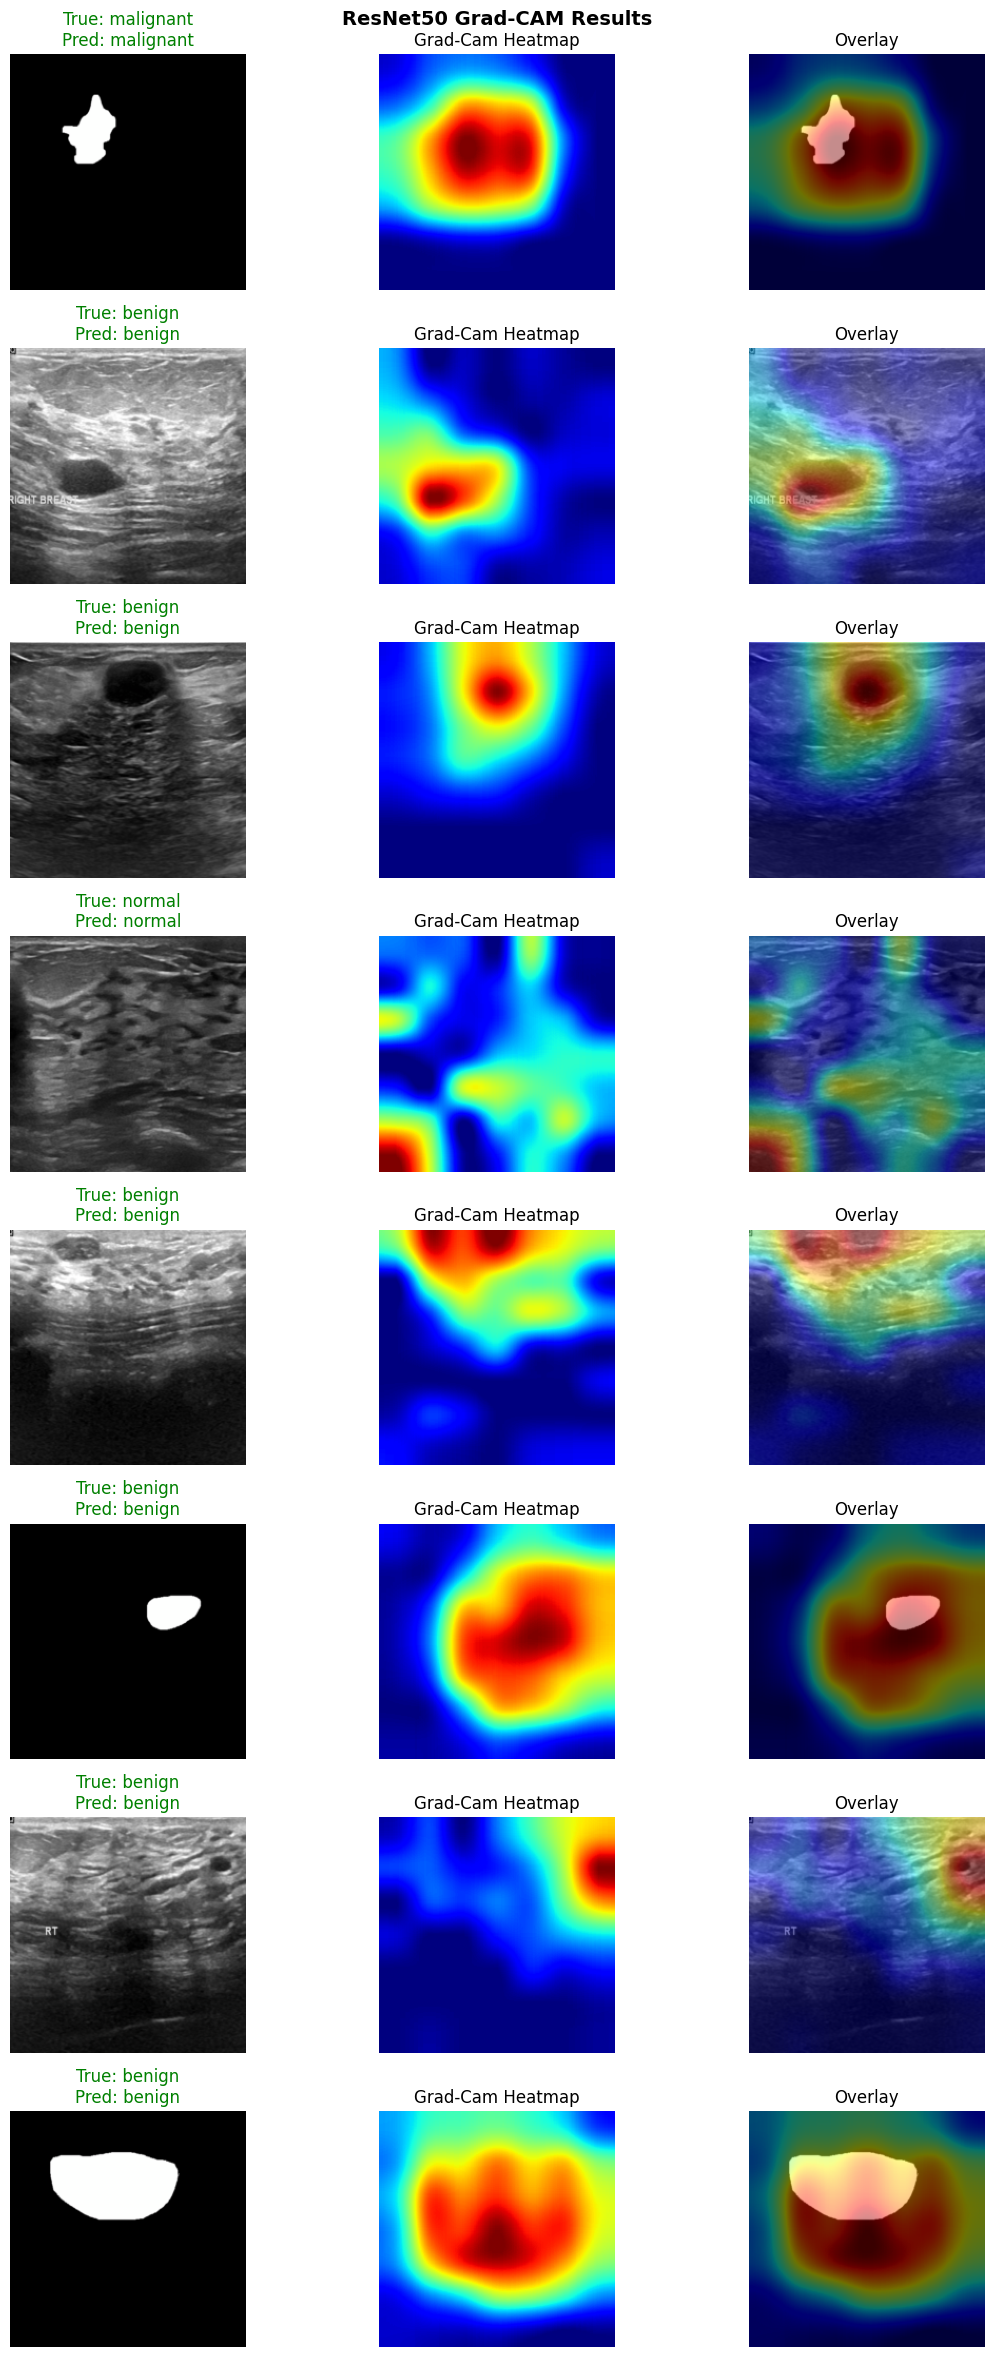

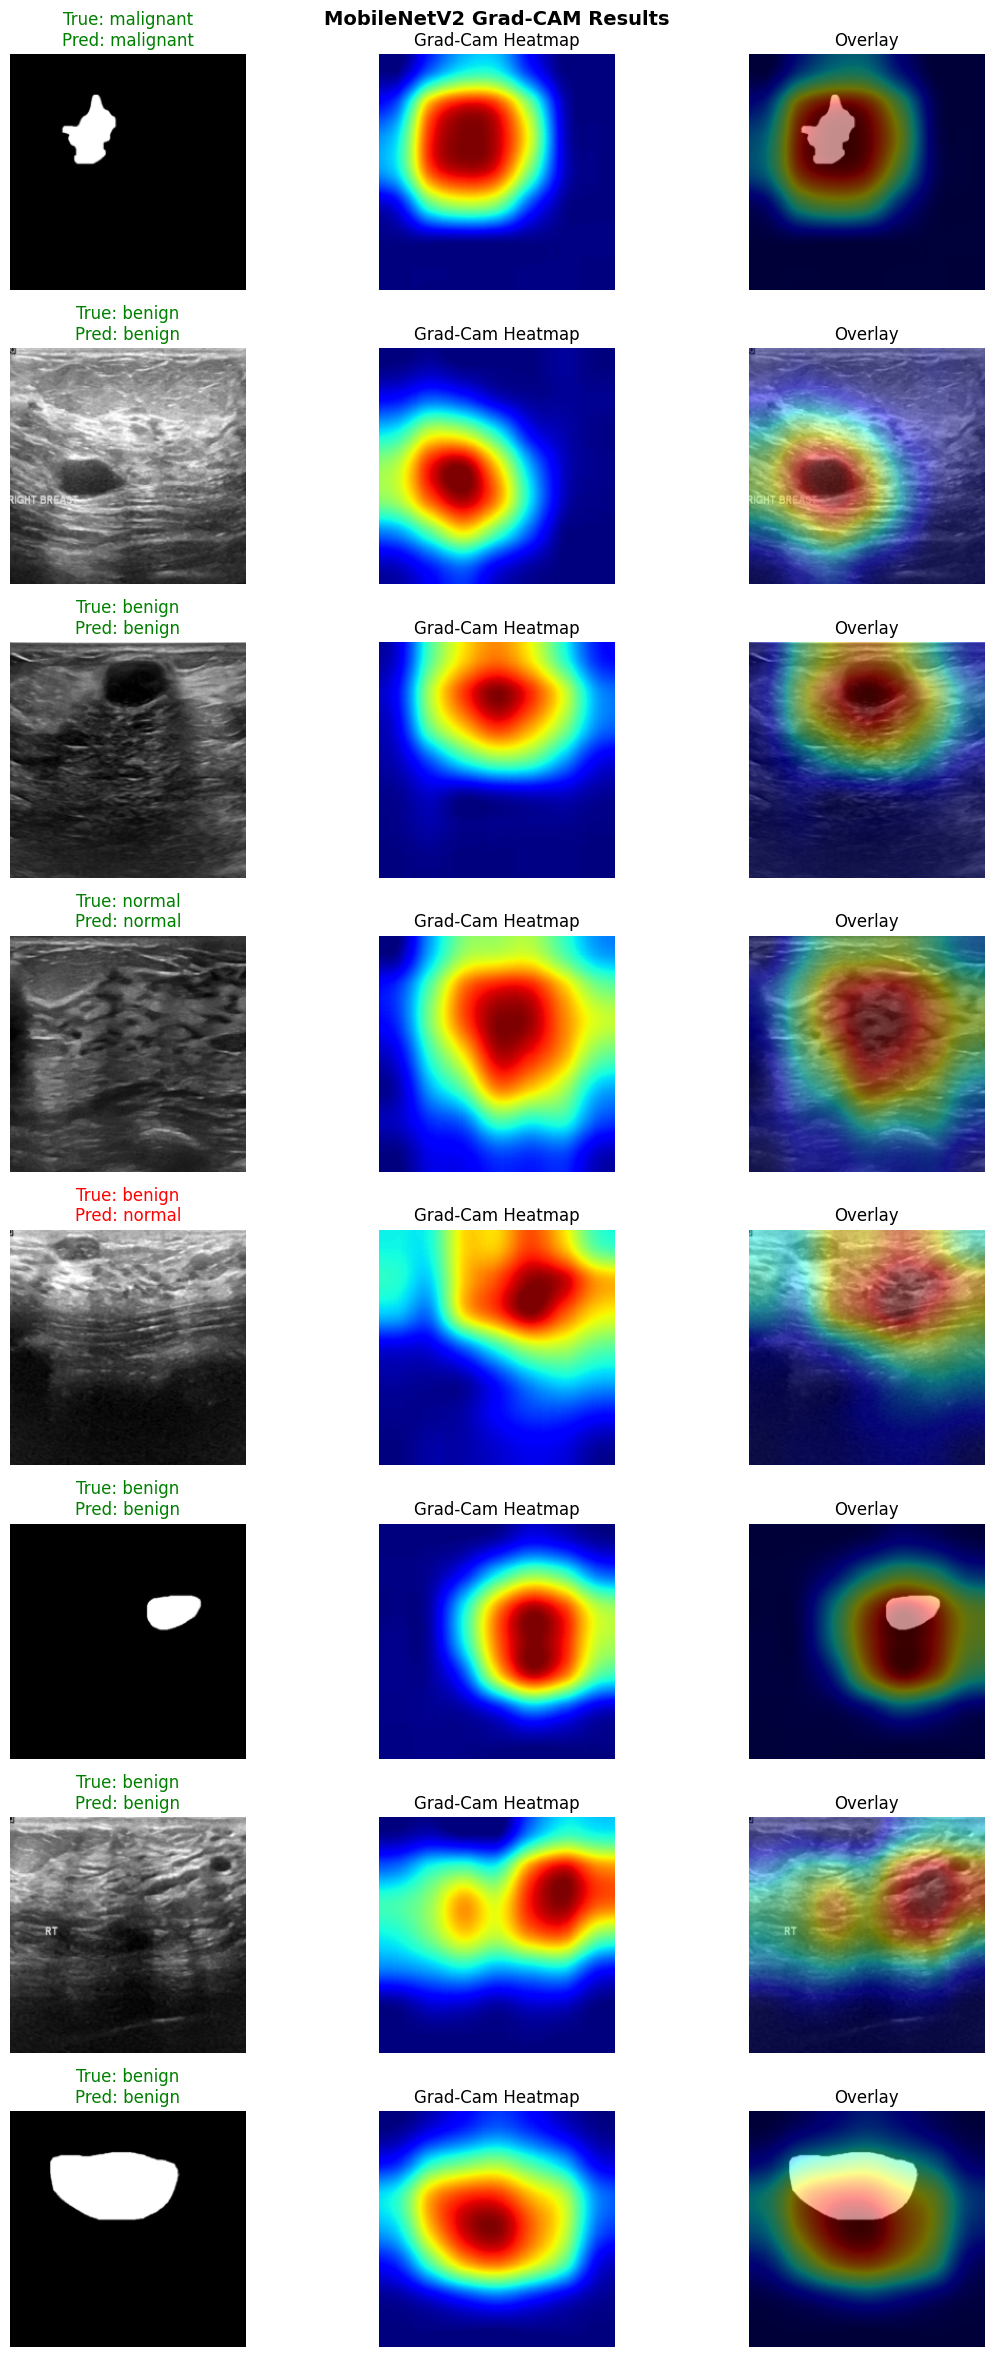

In [ ]:
indices = get_random_indices(test_dataset, 8)
class_names = test_loader.dataset.dataset.classes

show_gradcam(gradcam_cnn, "Custom CNN", indices, test_dataset, class_names)
show_gradcam(gradcam_resnet, "ResNet50", indices, test_dataset, class_names)
show_gradcam(gradcam_mobilenet, "MobileNetV2", indices, test_dataset, class_names)